In [1]:
#malumotlarni yuklash va ular bilan ishlash uchun
import pandas as pd
import numpy as np

#vizualizatsiya uchun
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

#ML
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn import metrics


In [2]:
#datasetni yuklash
train = pd.read_csv('https://raw.githubusercontent.com/botirTurgonboyev/Bankga-mijozlarining-qarzini-qaytarish-pragnozini-aniqlash/refs/heads/main/train.csv')
test = pd.read_csv('https://raw.githubusercontent.com/botirTurgonboyev/Bankga-mijozlarining-qarzini-qaytarish-pragnozini-aniqlash/refs/heads/main/test.csv')
submission = pd.read_csv('https://raw.githubusercontent.com/botirTurgonboyev/Bankga-mijozlarining-qarzini-qaytarish-pragnozini-aniqlash/refs/heads/main/sample_submission.csv')

In [3]:
#train
train.sample(5)

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
3160,3160,15607598.0,Chiang,597.0,France,Male,28.0,1.0,0.00,2.0,1.0,1.0,121551.93,0.0
2643,2643,15742824.0,Chidiebere,684.0,France,Female,25.0,7.0,80927.56,1.0,0.0,1.0,25339.29,0.0
7472,7472,15709232.0,Nnamdi,653.0,Spain,Male,36.0,8.0,152606.82,1.0,0.0,0.0,137898.56,1.0
623,623,15659327.0,Onyemauchechukwu,694.0,France,Female,51.0,4.0,0.00,1.0,1.0,0.0,68987.55,1.0
12404,12404,15670602.0,Hsia,709.0,Spain,Female,56.0,9.0,0.00,1.0,1.0,0.0,155876.06,1.0


## Ustunlar

* Customer ID: har bir mijoz uchun noyob identifikator
* Surname: mijozning familiyasi
* Credit score: mijozning kredit qobiliyatini ko‘rsatuvchi raqamli qiymat
* Geography: mijoz istiqomat qiladigan mamlakat (Fransiya, Ispaniya yoki Germaniya)
* Gender: mijozning jinsi (Male yoki Female)
* Age: mijozning yoshi
* Tenure: mijozning bank bilan ishlagan yillari soni
* Balance: mijozning hisobidagi pul miqdori
* NumOfProducts: mijoz foydalanayotgan bank mahsulotlari soni (masalan, jamg‘arma hisobi, kredit kartasi)
* HasCrCard: mijozda kredit kartasi bor-yo‘qligi (1 = bor, 0 = yo‘q)
* IsActiveMember: mijozning faol a’zo ekani (1 = ha, 0 = yo‘q)
* EstimatedSalary: mijozning taxminiy yillik daromadi



In [4]:
train.shape

(15000, 14)

In [5]:
# id ustuni bizga kerak emas
train = train.drop(columns=['id'])
train.shape

(15000, 13)

In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       15000 non-null  float64
 1   Surname          15000 non-null  object 
 2   CreditScore      15000 non-null  float64
 3   Geography        15000 non-null  object 
 4   Gender           15000 non-null  object 
 5   Age              15000 non-null  float64
 6   Tenure           15000 non-null  float64
 7   Balance          15000 non-null  float64
 8   NumOfProducts    15000 non-null  float64
 9   HasCrCard        15000 non-null  float64
 10  IsActiveMember   15000 non-null  float64
 11  EstimatedSalary  15000 non-null  float64
 12  Exited           15000 non-null  float64
dtypes: float64(10), object(3)
memory usage: 1.5+ MB


In [7]:
train.describe()

,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,1.500000e+04,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,1.579454e+07,657.856800,37.710133,5.018667,42338.107539,1.590533,0.779133,0.496000,116944.059867,0.198467
std,1.268495e+07,72.678739,8.144880,2.787407,59703.047751,0.525822,0.414845,0.500001,46047.485455,0.398859
min,1.567151e+05,431.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,11.580000,0.000000
25%,1.563435e+07,602.000000,32.000000,3.000000,0.000000,1.000000,1.000000,0.000000,82644.332500,0.000000
50%,1.568947e+07,661.000000,37.000000,5.000000,0.000000,2.000000,1.000000,0.000000,122449.420000,0.000000
75%,1.575682e+07,707.000000,42.000000,7.000000,109636.342500,2.000000,1.000000,1.000000,155703.022500,0.000000
max,1.569172e+09,850.000000,72.000000,10.000000,187911.550000,5.000000,1.000000,1.000000,885120.790000,1.000000


In [8]:
#qiymatlarni mavjudligini tekshiramiz

train.isnull().sum()

,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0
HasCrCard,0


In [9]:

train['Exited'].value_counts(normalize=True)

,proportion
Exited,
0.0,0.801533
1.0,0.198467


#Vizualizatsiya

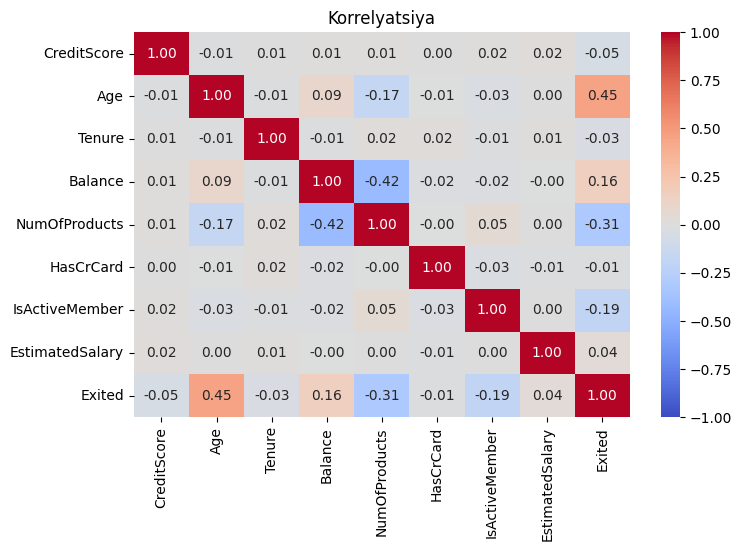

In [10]:
corr = train.drop(columns=['CustomerId']).corr(numeric_only=True)

plt.figure(figsize=(8, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Korrelyatsiya')
plt.show()

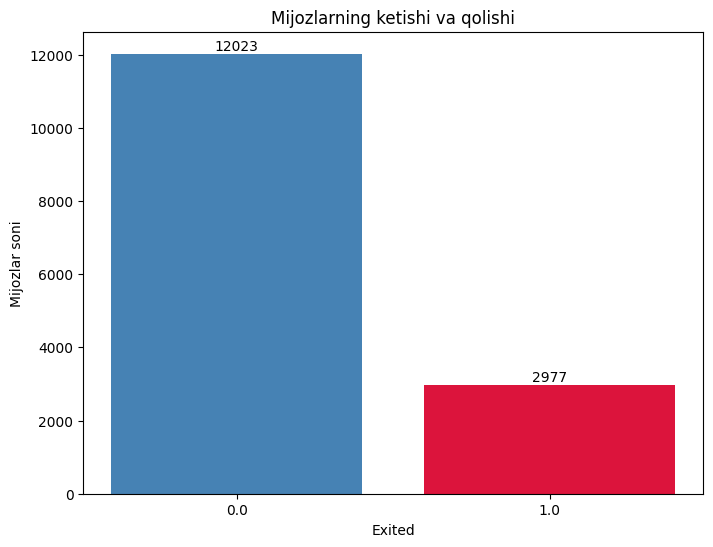

In [11]:
counts = train['Exited'].value_counts()

plt.figure(figsize=(8, 6))
plt.bar(counts.index.astype(str), counts.values, color=['steelblue', 'crimson'])
plt.title('Mijozlarning ketishi va qolishi')
plt.xlabel('Exited')
plt.ylabel('Mijozlar soni')
for i, v in enumerate(counts.values):
    plt.text(i, v + 100, str(v), ha='center')
plt.show()

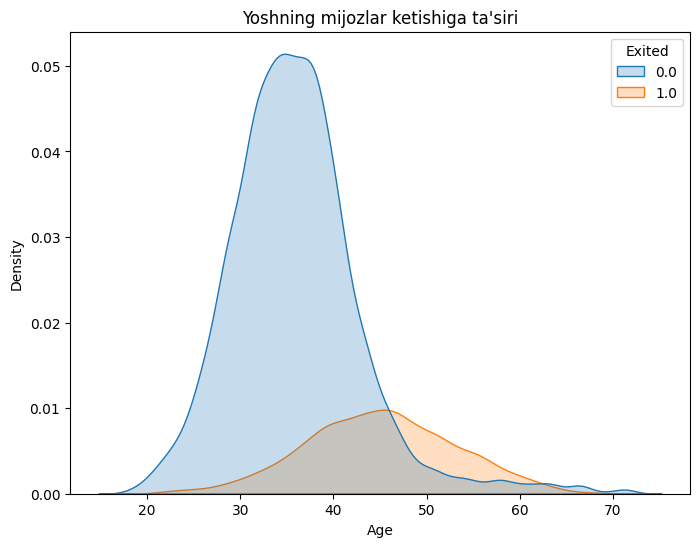

In [12]:
#Mijozlar ketishi va yoshi o'rtasidagi bog'liqlik

plt.figure(figsize=(8, 6))
sns.kdeplot(data=train, x='Age', hue='Exited', fill=True)
plt.title('Yoshning mijozlar ketishiga ta\'siri')
plt.show()

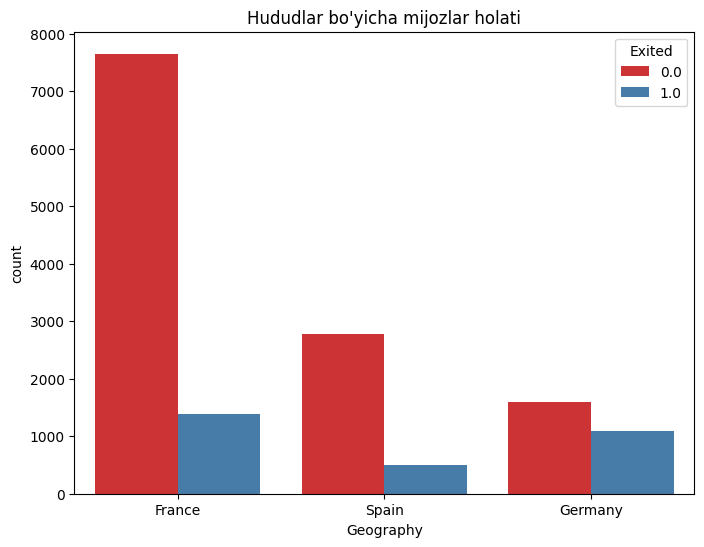

In [13]:
#Hudud bo'yicha ketishi

plt.figure(figsize=(8, 6))
sns.countplot(x='Geography', hue='Exited', data=train, palette='Set1')
plt.title('Hududlar bo\'yicha mijozlar holati')
plt.show()

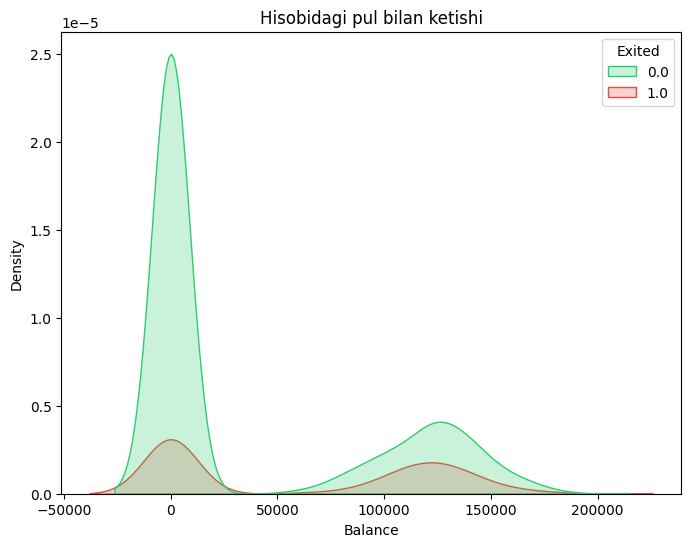

In [14]:
plt.figure(figsize=(8, 6))
sns.kdeplot(data=train, x='Balance', hue='Exited', fill=True,
            palette=['#2ecc71', '#e74c3c'])
plt.title('Hisobidagi pul bilan ketishi')
plt.show()


#ML ga tayyorlash

In [15]:
train.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15702656.0,Nwora,567.0,France,Male,33.0,9.0,0.0,2.0,1.0,0.0,156792.89,0.0
1,15647965.0,Yevdokimova,628.0,France,Female,38.0,3.0,0.0,1.0,1.0,1.0,51987.99,1.0
2,15798834.0,Ch'iu,635.0,France,Female,29.0,3.0,0.0,2.0,1.0,1.0,113079.19,0.0
3,15672056.0,Hsia,681.0,France,Male,28.0,6.0,0.0,2.0,1.0,0.0,14081.64,0.0
4,15759537.0,Okwudilichukwu,587.0,France,Female,27.0,5.0,0.0,2.0,1.0,0.0,158958.90,0.0


In [17]:

x = train.drop(columns=['Exited', 'Surname'])
y = train['Exited']

x = pd.get_dummies(x)

x.head()

,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
0,15702656.0,567.0,33.0,9.0,0.0,2.0,1.0,0.0,156792.89,True,False,False,False,True
1,15647965.0,628.0,38.0,3.0,0.0,1.0,1.0,1.0,51987.99,True,False,False,True,False
2,15798834.0,635.0,29.0,3.0,0.0,2.0,1.0,1.0,113079.19,True,False,False,True,False
3,15672056.0,681.0,28.0,6.0,0.0,2.0,1.0,0.0,14081.64,True,False,False,False,True
4,15759537.0,587.0,27.0,5.0,0.0,2.0,1.0,0.0,158958.90,True,False,False,True,False


In [18]:
scaler = StandardScaler()

In [19]:
x_scaled = scaler.fit_transform(x)

In [20]:
x_train, x_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.2, random_state=42)

#ML

              precision    recall  f1-score   support

         0.0       0.89      0.95      0.92      2424
         1.0       0.72      0.53      0.61       576

    accuracy                           0.87      3000
   macro avg       0.81      0.74      0.77      3000
weighted avg       0.86      0.87      0.86      3000

Model aniqligi : 0.8706666666666667


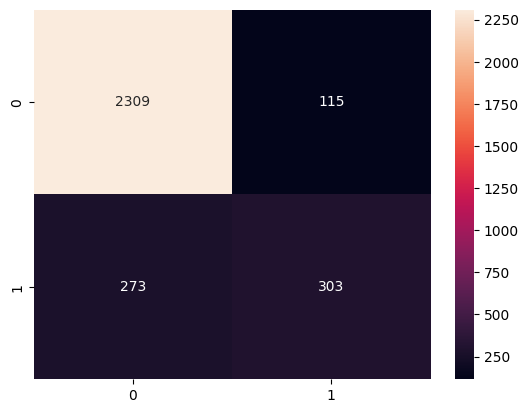

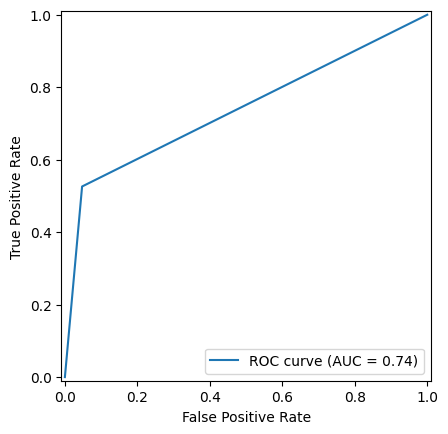

In [22]:
#Logistic Regression

LR_model = LogisticRegression()
LR_model.fit(x_train, y_train)

#Natija

y_predict = LR_model.predict(x_test)

#Xatolikni baholash

print(classification_report(y_test, y_predict))
print(f'Model aniqligi : {accuracy_score(y_test, y_predict)}')

## confusion matrix
conf_mat = confusion_matrix(y_test, y_predict)
sns.heatmap(conf_mat, annot=True,fmt="g")
plt.show()

## ROC curve
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_predict)
roc_auc = metrics.auc(fpr, tpr)
display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name='ROC curve')
display.plot()
plt.show()

              precision    recall  f1-score   support

         0.0       0.91      0.96      0.93      2424
         1.0       0.77      0.61      0.69       576

    accuracy                           0.89      3000
   macro avg       0.84      0.79      0.81      3000
weighted avg       0.89      0.89      0.89      3000

Model aniqligi: 0.8916666666666667


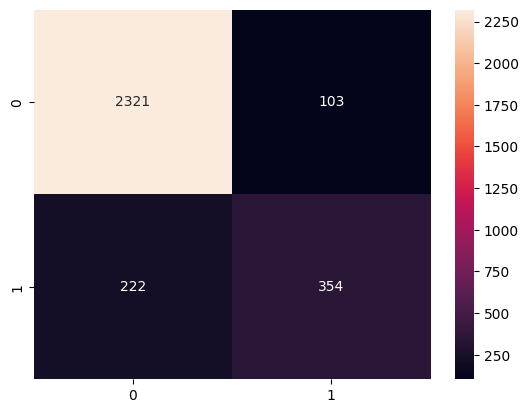

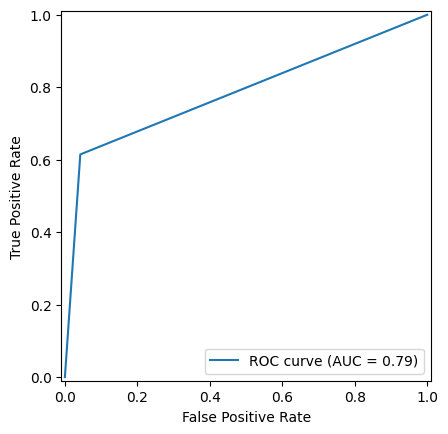

In [23]:
# svc
svm_model = SVC()
svm_model.fit(x_train, y_train)

# Modelni baholaymiz
y_pred = svm_model.predict(x_test)
print(metrics.classification_report(y_test, y_pred))
print("Model aniqligi:", metrics.accuracy_score(y_test,y_pred))

## confusion matrix
conf_mat = metrics.confusion_matrix(y_test, y_pred)
sns.heatmap(conf_mat, annot=True,fmt="g")
plt.show()

## ROC curve
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred)
roc_auc = metrics.auc(fpr, tpr)
display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name='ROC curve')
display.plot()
plt.show()

              precision    recall  f1-score   support

         0.0       0.91      0.89      0.90      2424
         1.0       0.59      0.64      0.61       576

    accuracy                           0.85      3000
   macro avg       0.75      0.77      0.76      3000
weighted avg       0.85      0.85      0.85      3000

Model aniqligi: 0.8453333333333334


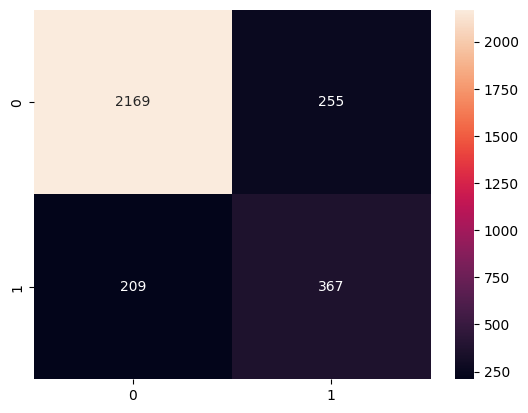

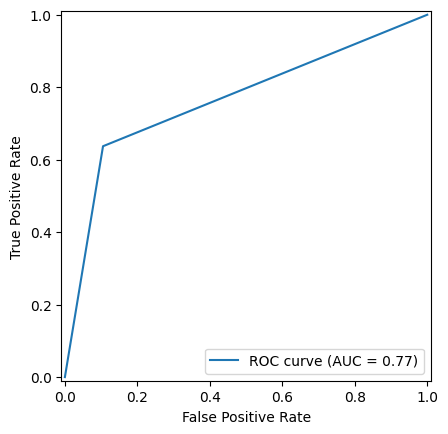

In [24]:
# DecisionTree
tree_model = DecisionTreeClassifier()
tree_model.fit(x_train, y_train)

# Modelni baholaymiz
y_pred = tree_model.predict(x_test)
print(metrics.classification_report(y_test, y_pred))
print("Model aniqligi:", metrics.accuracy_score(y_test,y_pred))

## confusion matrix
conf_mat = metrics.confusion_matrix(y_test, y_pred)
sns.heatmap(conf_mat, annot=True,fmt="g")
plt.show()

## ROC curve
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred)
roc_auc = metrics.auc(fpr, tpr)
display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name='ROC curve')
display.plot()
plt.show()

              precision    recall  f1-score   support

         0.0       0.92      0.94      0.93      2424
         1.0       0.73      0.64      0.68       576

    accuracy                           0.89      3000
   macro avg       0.83      0.79      0.81      3000
weighted avg       0.88      0.89      0.88      3000

Model aniqligi: 0.8863333333333333


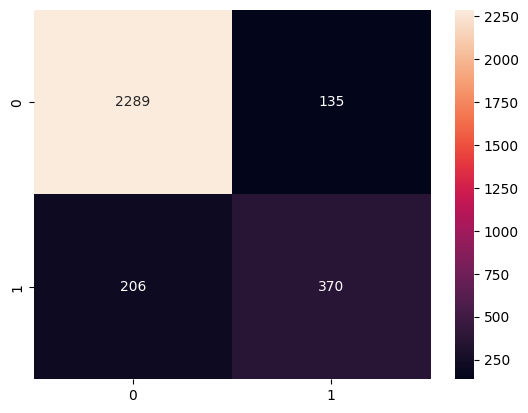

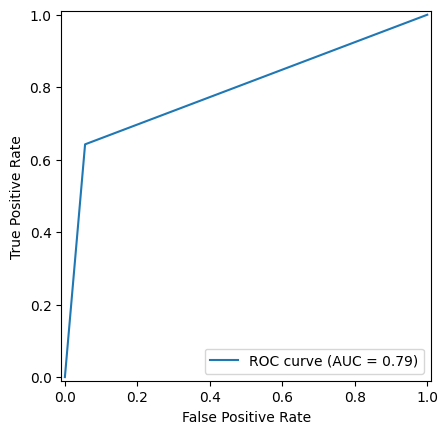

In [25]:
# RandomForest
RF_model = RandomForestClassifier(n_estimators=9)
RF_model.fit(x_train, y_train)

# Modelni baholaymiz
y_pred = RF_model.predict(x_test)
print(classification_report(y_test, y_pred))
print("Model aniqligi:", accuracy_score(y_test,y_pred))

## confusion matrix
conf_mat = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_mat, annot=True,fmt="g")
plt.show()

## ROC curve
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred)
roc_auc = metrics.auc(fpr, tpr)
display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name='ROC curve')
display.plot()
plt.show()

              precision    recall  f1-score   support

         0.0       0.92      0.94      0.93      2424
         1.0       0.72      0.66      0.69       576

    accuracy                           0.89      3000
   macro avg       0.82      0.80      0.81      3000
weighted avg       0.88      0.89      0.88      3000

Model aniqligi: 0.8866666666666667


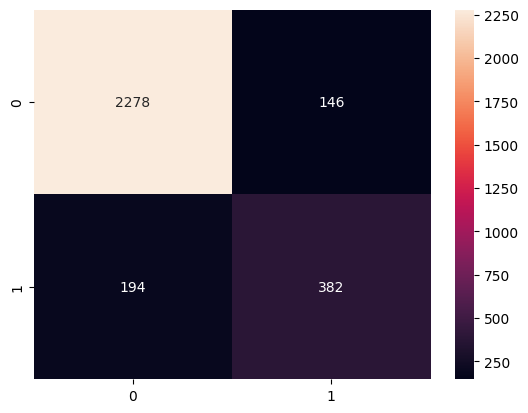

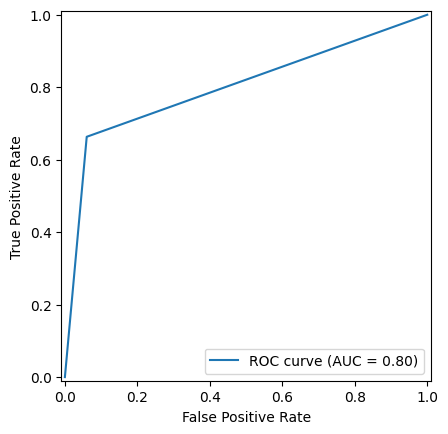

In [26]:
# XGBoost
xgb_model = XGBClassifier()
xgb_model.fit(x_train, y_train)

# Modelni baholaymiz
y_pred = xgb_model.predict(x_test)
print(classification_report(y_test, y_pred))
print("Model aniqligi:", accuracy_score(y_test,y_pred))

## confusion matrix
conf_mat = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_mat, annot=True,fmt="g")
plt.show()

## ROC curve
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred)
roc_auc = metrics.auc(fpr, tpr)
display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name='ROC curve')
display.plot()
plt.show()

ROC curve eng yaxshi natija chiqargan modelni tanlaymiz

In [28]:
#XGBoost tanladim test datasetni shu model bilan bashorat qilamiz

In [50]:
test.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,15000,15732563.0,Hs?,707.0,Germany,Male,21.0,4.0,114513.66,2.0,1.0,0.0,176692.87
1,15001,15727041.0,Ma,678.0,Germany,Male,33.0,5.0,142510.50,1.0,0.0,0.0,52820.13
2,15002,15753679.0,K?,636.0,Spain,Male,45.0,9.0,0.00,2.0,1.0,1.0,125062.02
3,15003,15581554.0,H?,697.0,Spain,Male,46.0,8.0,0.00,2.0,1.0,0.0,131647.41
4,15004,15773723.0,Bellucci,553.0,Spain,Male,31.0,2.0,0.00,2.0,1.0,0.0,58814.41


In [38]:
df = test.drop(['id', 'Surname'], axis=1)
df.head()

,CustomerId,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,15732563.0,707.0,Germany,Male,21.0,4.0,114513.66,2.0,1.0,0.0,176692.87
1,15727041.0,678.0,Germany,Male,33.0,5.0,142510.50,1.0,0.0,0.0,52820.13
2,15753679.0,636.0,Spain,Male,45.0,9.0,0.00,2.0,1.0,1.0,125062.02
3,15581554.0,697.0,Spain,Male,46.0,8.0,0.00,2.0,1.0,0.0,131647.41
4,15773723.0,553.0,Spain,Male,31.0,2.0,0.00,2.0,1.0,0.0,58814.41


In [39]:
df = pd.get_dummies(df)
df.shape

(10000, 14)

In [40]:

x = scaler.transform(df)
x

array([[-4.88583288e-03,  6.76192774e-01, -2.05168042e+00, ...,
        -5.29021248e-01, -8.77089054e-01,  8.77089054e-01],
       [-5.32116642e-03,  2.77163194e-01, -5.78313060e-01, ...,
        -5.29021248e-01, -8.77089054e-01,  8.77089054e-01],
       [-3.22112753e-03, -3.00741715e-01,  8.95054301e-01, ...,
         1.89028324e+00, -8.77089054e-01,  8.77089054e-01],
       ...,
       [-1.65542222e-02, -1.36023405e+00,  1.75451859e+00, ...,
         1.89028324e+00, -8.77089054e-01,  8.77089054e-01],
       [-1.20581933e-02,  2.10719541e+00, -9.46654900e-01, ...,
        -5.29021248e-01,  1.14013508e+00, -1.14013508e+00],
       [ 2.60570112e-05, -9.19925546e-01,  4.03931847e-01, ...,
        -5.29021248e-01, -8.77089054e-01,  8.77089054e-01]])

In [42]:
y_predd = xgb_model.predict(x)
y_predd

array([0, 0, 0, ..., 1, 0, 0])

In [45]:
y_pred_proba = xgb_model.predict_proba(x)[:, 1]
y_pred_proba

array([0.02570919, 0.03431673, 0.04571483, ..., 0.9988532 , 0.01984941,
       0.07773815], dtype=float32)

In [47]:
y_pred_proba.shape

(10000,)

In [51]:
bashorat = pd.DataFrame({'id':test.id,
                         "Exited":y_pred_proba})
bashorat.head()

,id,Exited
0,15000,0.025709
1,15001,0.034317
2,15002,0.045715
3,15003,0.039791
4,15004,0.001467


In [52]:
submission.head()

,id,Exited
0,15000,0.5
1,15001,0.5
2,15002,0.5
3,15003,0.5
4,15004,0.5


In [55]:
compare_df = pd.DataFrame({
    'Haqiqiy (y_test)': submission.Exited,
    'Bashorat ehtimollik (y_proba)': y_pred_proba
}).reset_index(drop=True)

compare_df.head(10)

,Haqiqiy (y_test),Bashorat ehtimollik (y_proba)
0,0.5,0.025709
1,0.5,0.034317
2,0.5,0.045715
3,0.5,0.039791
4,0.5,0.001467
5,0.5,0.899783
6,0.5,0.053285
7,0.5,0.927326
8,0.5,0.000899
9,0.5,0.068188


In [57]:
bashorat.to_csv('bashorat.csv')
compare_df.to_csv('haqiqiy_vs_bashorat.csv')